Script
- Filters and pre-processes the query data before clustering.
- Input: Binned query data file.

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import anndata as ad
import seaborn as sns
from datetime import datetime
import time, gc, warnings, pickle, os, re
from PIL import Image, ImageColor
import random, matplotlib
from scipy.sparse import csr_matrix, hstack, coo_matrix
from scipy.stats import gaussian_kde
# from KDEpy import FFTKDE
from scipy.signal import convolve2d
from scipy.sparse import vstack
from scipy import signal
import ipyparallel as ipp
from matplotlib.colors import ListedColormap
from PIL import ImageColor
from matplotlib.ticker import AutoMinorLocator
import matplotlib.cm as cm

In [2]:
def plot_shape(convolv_matrix, data, vmax_adjust=0.5, mask=np.ones((5000,5000))):
    x = data[:,1]
    y = data[:,0]
    plt.figure(figsize=(10,10))
    ax_0 = plt.subplot2grid((5,5), (0,0), colspan=4)
    ax_1 = plt.subplot2grid((5,5), (1,0), colspan=4, rowspan=4)
    ax_2 = plt.subplot2grid((5,5), (1,4), rowspan=4)
    hist_x = ax_0.hist(x, bins=50)
    hist_2d = ax_1.imshow((convolv_matrix*mask)[::-1,:], vmax=vmax_adjust*convolv_matrix.max(), cmap='magma')
    hist_y = ax_2.hist(y, bins=50, orientation='horizontal')
    ax_0.set_xticklabels([])
    ax_2.set_yticklabels([])
    ax_1.set_yticks(ticks=list(range(0,5001,1000)))
    ax_1.set_yticklabels(labels=[str(x) for x in list(range(5000,-1,-1000))])
    ax_1.set_xlabel('zipcode index')
    ax_1.set_ylabel('zipcode index')
    ax_0.grid(False)
    ax_1.grid(False)
    ax_2.grid(False)
    
def plot_gene(gene_name, adata, s=3, vmax_adjust=0.5, bw=5, mask=np.ones((5000,5000))): 
    plt.figure(figsize = (16,16))
    gene_idx = adata.var.reset_index().query('gene_name == @gene_name').index
    gene_data = csr_matrix((adata.X[:,gene_idx].reshape(5000,5000).toarray())*mask).tocoo()
    x_u, y_u = gene_data.row.reshape(-1,1), gene_data.col.reshape(-1,1)
    coord_list = np.hstack([x_u, y_u])
    count_list = gene_data.data.astype(int)
    total_list = [list(coord)*count for coord,count in zip(coord_list,count_list)]
    data = np.concatenate(total_list).reshape(-1,2)
    grid_xy = np.meshgrid(np.arange(-1,5001), np.arange(-1,5001))
    grid = np.hstack([grid_xy[1].reshape(-1,1), grid_xy[0].reshape(-1,1)])
    kde = FFTKDE(kernel='gaussian', bw=bw)
    points = kde.fit(data).evaluate(grid)
    z = points.reshape((5002,5002))[1:5001,1:5001][x_u,y_u]
    plt.figure(figsize=(12,12))
    plt.scatter(y_u, x_u, c=z, marker='h', s=s, edgecolor='none',
                       cmap='magma_r', vmin=0, vmax=vmax_adjust*max(z))
    plt.xlim(-250, 5350)
    plt.ylim(-250, 5350)
    plt.gca().set_aspect('equal')
    plt.title('%s mapped zipcode positions' % gene_name)
    plt.xlabel('zipcode index')
    plt.ylabel('zipcode index')
    plt.grid(False)
    print('plotted %s' % gene_name)
    


def plot_convolv_gene(adata, s=3, vmax_adjust=0.5, core_size=50, std=25, mask=np.ones((5000,5000))): 
    plt.figure(figsize = (16,16))
    gene_data = (adata.X.reshape(25000000,-1).sum(1).reshape(5000,5000).toarray())
    kernel = np.outer(signal.windows.gaussian(core_size, std),
                  signal.windows.gaussian(core_size, std))
    gmatrix = signal.fftconvolve(gene_data, kernel, mode='same')
    gene_data = coo_matrix(gene_data)
    x_u, y_u = gene_data.row.reshape(-1,1), gene_data.col.reshape(-1,1)
    z = gmatrix[x_u,y_u]
    plt.figure(figsize=(12,12))
    plt.scatter(y_u, x_u, c=z, marker='h', s=s, edgecolor='none',
                       cmap='magma_r', vmin=0, vmax=vmax_adjust*max(z))
    plt.xlim(-250, 5350)
    plt.ylim(-250, 5350)
    plt.gca().set_aspect('equal')
    plt.title('Sample shape')
    plt.xlabel('zipcode index')
    plt.ylabel('zipcode index')
    plt.grid(False)
    
def plot_gene_bg(bg, alpha, gene_name, adata, s=3, vmax_adjust=0.5, core_size=50, std=25, mask=np.ones((5000,5000))): 
    plt.figure(figsize = (16,16))
    gene_idx = adata.var.reset_index().query('gene_name == @gene_name').index
    gene_data = (adata.X[:,gene_idx].reshape(5000,5000).toarray())*mask
    kernel = np.outer(signal.windows.gaussian(core_size, std),
                  signal.windows.gaussian(core_size, std))
    gmatrix = signal.fftconvolve(gene_data, kernel, mode='same')
    gene_data = coo_matrix(gene_data)
    x_u, y_u = gene_data.row.reshape(-1,1), gene_data.col.reshape(-1,1)
    z = gmatrix[x_u,y_u]
    plt.figure(figsize=(12,12))
    plt.scatter(y_u, x_u, c=z, marker='h', s=s, edgecolor='none',
                       cmap='magma_r', vmin=0, vmax=vmax_adjust*max(z))
    plt.imshow(bg, extent=[0, 4999, 0, 4999], alpha=alpha)
    plt.xlim(0, 4999)
    plt.ylim(0, 4999)
    plt.gca().set_aspect('equal')
    plt.title('%s mapped zipcode positions' % gene_name)
    plt.xlabel('zipcode index')
    plt.ylabel('zipcode index')
    plt.grid(False)
    print('plotted %s' % gene_name)
    
def plot_gene_conv(gene_name, adata, s=3, vmax_adjust=0.5, core_size=50, std=25, mask=np.ones((5000,5000))): 
    plt.figure(figsize = (16,16))
    gene_idx = adata.var.reset_index().query('gene_name == @gene_name').index
    gene_data = (adata.X[:,gene_idx].reshape(5000,5000).toarray())*mask
    kernel = np.outer(signal.windows.gaussian(core_size, std),
                  signal.windows.gaussian(core_size, std))
    gmatrix = signal.fftconvolve(gene_data, kernel, mode='same')
    gene_data = coo_matrix(gene_data)
    x_u, y_u = gene_data.row.reshape(-1,1), gene_data.col.reshape(-1,1)
    z = gmatrix[x_u,y_u]
    plt.figure(figsize=(12,12))
    plt.scatter(y_u, x_u, c=z, marker='h', s=s, edgecolor='none',
                       cmap='magma_r', vmin=0, vmax=vmax_adjust*max(z))
    plt.xlim(-250, 5350)
    plt.ylim(-250, 5350)
    plt.gca().set_aspect('equal')
    plt.title('%s mapped zipcode positions' % gene_name)
    plt.xlabel('zipcode index')
    plt.ylabel('zipcode index')
    plt.grid(False)
    print('plotted %s' % gene_name)
    
def plot_gene_ax(ax, gene_name, adata, s=3, vmax_adjust=0.5, bw=5, mask=np.ones((5000,5000))): 
    gene_idx = adata.var.reset_index().query('gene_name == @gene_name').index
    gene_data = csr_matrix((adata.X[:,gene_idx].reshape(5000,5000).toarray())*mask).tocoo()
    x_u, y_u = gene_data.row.reshape(-1,1), gene_data.col.reshape(-1,1)
    coord_list = np.hstack([x_u, y_u])
    count_list = gene_data.data.astype(int)
    total_list = [list(coord)*count for coord,count in zip(coord_list,count_list)]
    data = np.concatenate(total_list).reshape(-1,2)
    grid_xy = np.meshgrid(np.arange(-1,5001), np.arange(-1,5001))
    grid = np.hstack([grid_xy[1].reshape(-1,1), grid_xy[0].reshape(-1,1)])
    # kde = FFTKDE(kernel='gaussian', bw=bw)
    points = kde.fit(data).evaluate(grid)
    z = points.reshape((5002,5002))[1:5001,1:5001][x_u,y_u]
    ax.grid(False)
    ax.scatter(y_u, x_u, c=z, marker='h', s=s, edgecolor='none',
                       cmap='magma_r', vmin=0, vmax=vmax_adjust*max(z))
    ax.set_xlim(0, 5000)
    ax.set_ylim(0, 5000)
    ax.set_aspect('equal')
    ax.set_title('%s mapped zipcode positions' % gene_name)
    ax.set_xlabel('zipcode index')
    ax.set_ylabel('zipcode index')
    print('plotted %s' % gene_name)
    
def plot_group(adata_bin, group, cmap):
    bin_size =adata_bin.uns['bin_size']
    l2 = 5000 / bin_size
    conv_size =5
    l3 = l2 - conv_size + 1
    group = str(group)
    df_generank = sc.get.rank_genes_groups_df(adata_bin, group=group)
    #df_generank = df_generank.query('logfoldchanges > 2')
    fig, axs = plt.subplots(1, 6, figsize=(24, 4))
    ##### plot of data, groups in drop_list will not show
    df_group = adata_bin.obs.query('leiden == @group')

    z = z0.copy()
    x = df_group['array_col'].astype(int)
    y = df_group['array_row'].astype(int)
    z[5000//bin_size-1-y, x] = int(group)+1

    z1 = np.array([cmap[x] for x in z.reshape(-1)]).reshape(l3, l3,3)
    plt.tight_layout()
    axs[0].imshow(z1)
    axs[0].grid(False)
    axs[0].set_title('Distribution of group #%s' % group)
    axs[0].set_aspect('equal')
    axs[0].set_yticks(ticks=list(range(0,5000//(bin_size)+1,5000//(bin_size*5))))
    axs[0].set_yticklabels(labels=[str(x) for x in list(range(5000,-1,-1000))])
    axs[0].set_xticks(ticks=list(range(0,5000//(bin_size)+1,5000//(bin_size*5))))
    axs[0].set_xticklabels(labels=[str(x) for x in list(range(0,5001,1000))])
    for i, name in enumerate(list(df_generank['names'][:5])):
        plot_gene_ax(axs[i+1], name, adata_ori, 2, 0.8, 20, mask)
    plt.grid(False)
    plt.show()
    plt.close


In [ ]:
adata_bin = sc.read_h5ad("/path/to/file/adata_binned_5_features.h5ad")

In [4]:
bin_size = 5
l = 5000
conv_size = 5
l2 = l // bin_size
l3 = l2 - conv_size + 1

In [5]:
adata_bin

AnnData object with n_obs × n_vars = 992016 × 19833
    obs: 'array_col', 'array_row'
    var: 'gene_ids', 'total_counts'
    uns: 'input_files', 'total_counts', 'total_genes'

In [6]:
adata_bin.obs['ngenes'] = (adata_bin.X > 0).sum(axis = 1)

In [7]:
adata_bin.uns = {'bin_size': bin_size, 'conv_size': conv_size, 'l': l, 'l2': l2, 'l3': l3}

/tmp/ipykernel_550720/1990103300.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata_bin.obs["total_counts"], kde=False, ax=axs[0])
/tmp/ipykernel_550720/1990103300.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata_bin.obs["ngenes"], kde=False, bins=60, ax=axs[1])


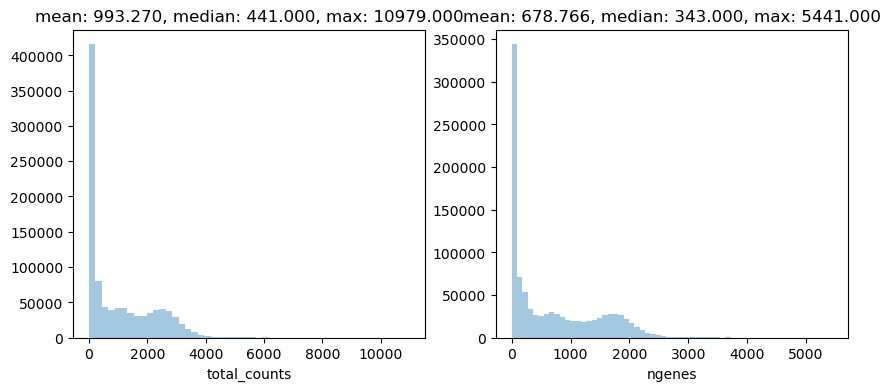

In [8]:
#Generating mitochondria QC variables
sc.pp.calculate_qc_metrics(adata_bin, inplace=True)
#generate QC plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.distplot(adata_bin.obs["total_counts"], kde=False, ax=axs[0])
axs[0].title.set_text('mean: %.3f, median: %.3f, max: %.3f' % (adata_bin.obs["total_counts"].mean(), adata_bin.obs["total_counts"].median(), adata_bin.obs["total_counts"].max()))
sns.distplot(adata_bin.obs["ngenes"], kde=False, bins=60, ax=axs[1])
axs[1].title.set_text('mean: %.3f, median: %.3f, max: %.3f' % (adata_bin.obs["ngenes"].mean(), adata_bin.obs["ngenes"].median(), adata_bin.obs["ngenes"].max()))
# fig.savefig(f'{output_dir}/raw_qc.png')

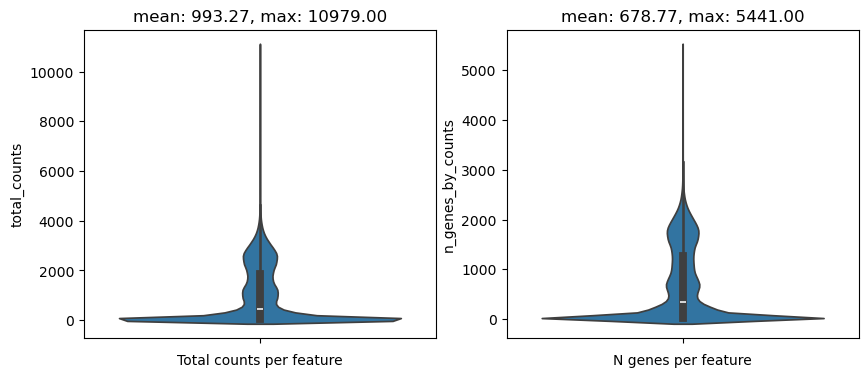

In [9]:
#generate QC plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
count_array = adata_bin.obs["total_counts"]
sns.violinplot(y = count_array, ax=axs[0])
axs[0].set_xlabel('Total counts per feature')
axs[0].title.set_text('mean: %.2f, max: %.2f' % (count_array.mean(), count_array.max()))
ngene_array = adata_bin.obs["n_genes_by_counts"]
sns.violinplot(y = ngene_array, ax=axs[1])
axs[1].set_xlabel('N genes per feature')
axs[1].title.set_text('mean: %.2f, max: %.2f' % (ngene_array.mean(), ngene_array.max()))
# fig.savefig(f'{output_dir}/qc_tissue2.png')
#axs[0].grid(False)
#axs[1].grid(False)

In [10]:
adata_bin

AnnData object with n_obs × n_vars = 992016 × 19833
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3'

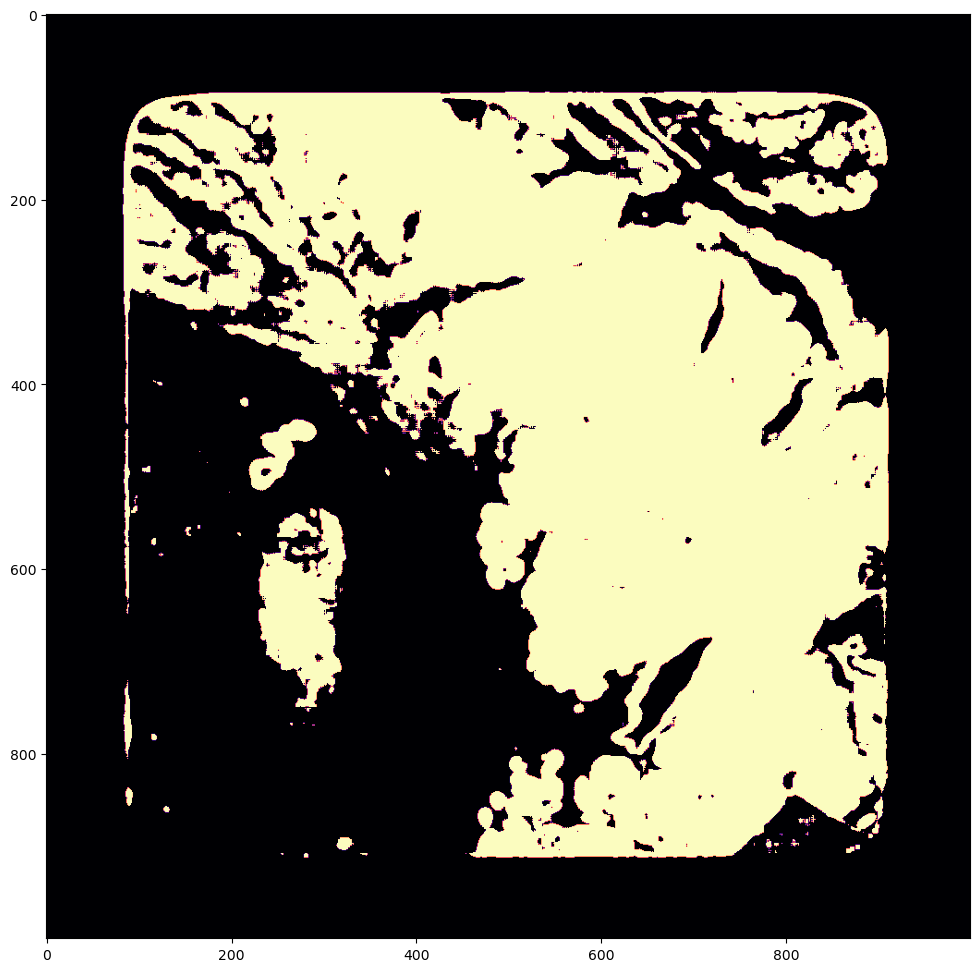

In [12]:
#test the tissue shape with each threshold
#the filter is NOT applied in this step, just a test. Play with different threds
thred = 1000
df_count = adata_bin.obs[['total_counts', 'array_col', 'array_row']].copy()
df_count = df_count[df_count.total_counts > thred]
df_count

l3 = max(df_count['array_row'].max(), df_count['array_col'].max()) + 1
# z0 = np.zeros((l3, l3))

# z0 = np.zeros((l3, l3))
z0 = np.zeros((l2, l2))
z0[df_count['array_row'], df_count['array_col']] = -1
# # z0 = np.zeros((5000//bin_size,5000//bin_size))
# # z0[5000//bin_size-1-df_count['array_row'], df_count['array_col']] = -1
plt.figure(figsize=(12,12))
plt.imshow(-z0, cmap='magma')

In [13]:
# # cannot be un-done.
sc.pp.filter_cells(adata_bin, min_counts=thred)

In [14]:
adata_bin

AnnData object with n_obs × n_vars = 390695 × 19833
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3'

/tmp/ipykernel_550720/3102371512.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata_bin.obs["total_counts"], kde=False, ax=axs[0])
/tmp/ipykernel_550720/3102371512.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata_bin.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])


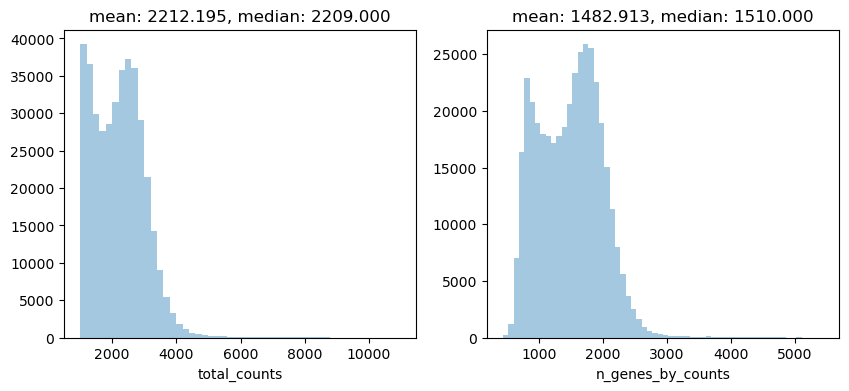

In [15]:
#generate QC plot after filtering
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.distplot(adata_bin.obs["total_counts"], kde=False, ax=axs[0])
axs[0].title.set_text('mean: %.3f, median: %.3f' % (adata_bin.obs["total_counts"].mean(), adata_bin.obs["total_counts"].median()))
sns.distplot(adata_bin.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])
axs[1].title.set_text('mean: %.3f, median: %.3f' % (adata_bin.obs["n_genes_by_counts"].mean(), adata_bin.obs["n_genes_by_counts"].median()))
# fig.savefig(f'{output_dir}/qc_tissue.png')

In [16]:
# the y-axis should be number of cells after binning or number of binned spots.

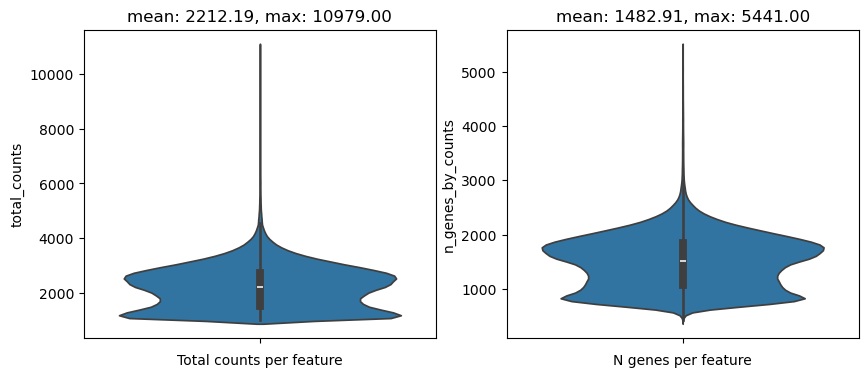

In [17]:
#generate QC plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
count_array = adata_bin.obs["total_counts"]
sns.violinplot(y = count_array, ax=axs[0])
axs[0].set_xlabel('Total counts per feature')
axs[0].title.set_text('mean: %.2f, max: %.2f' % (count_array.mean(), count_array.max()))
ngene_array = adata_bin.obs["n_genes_by_counts"]
sns.violinplot(y = ngene_array, ax=axs[1])
axs[1].set_xlabel('N genes per feature')
axs[1].title.set_text('mean: %.2f, max: %.2f' % (ngene_array.mean(), ngene_array.max()))
# fig.savefig(f'{output_dir}/qc_tissue2.png')
#axs[0].grid(False)
#axs[1].grid(False)

In [18]:
adata_bin

AnnData object with n_obs × n_vars = 390695 × 19833
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3'

In [19]:
min_genes=500
min_cells=200

In [20]:
sc.pp.filter_cells(adata_bin, min_genes=min_genes)
sc.pp.filter_genes(adata_bin, min_cells=min_cells)
sc.pp.normalize_total(adata_bin, inplace=True)
sc.pp.log1p(adata_bin)

In [21]:
adata_bin

AnnData object with n_obs × n_vars = 390592 × 17658
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'n_cells'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3', 'log1p'

/tmp/ipykernel_550720/3102371512.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata_bin.obs["total_counts"], kde=False, ax=axs[0])
/tmp/ipykernel_550720/3102371512.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(adata_bin.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])


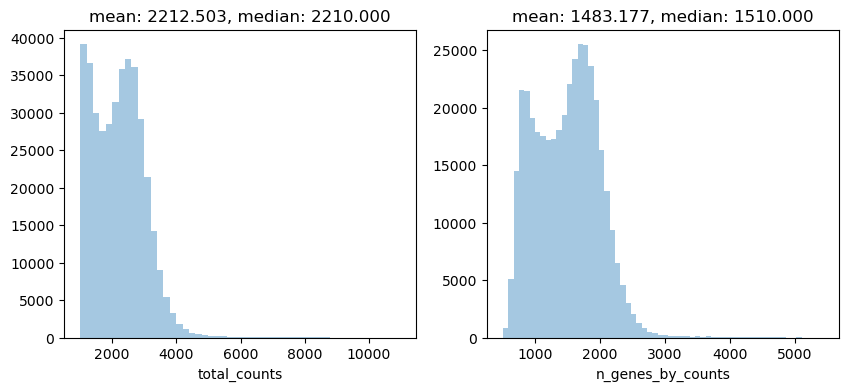

In [22]:
#generate QC plot after filtering
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.distplot(adata_bin.obs["total_counts"], kde=False, ax=axs[0])
axs[0].title.set_text('mean: %.3f, median: %.3f' % (adata_bin.obs["total_counts"].mean(), adata_bin.obs["total_counts"].median()))
sns.distplot(adata_bin.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])
axs[1].title.set_text('mean: %.3f, median: %.3f' % (adata_bin.obs["n_genes_by_counts"].mean(), adata_bin.obs["n_genes_by_counts"].median()))
# fig.savefig(f'{output_dir}/qc_tissue.png')

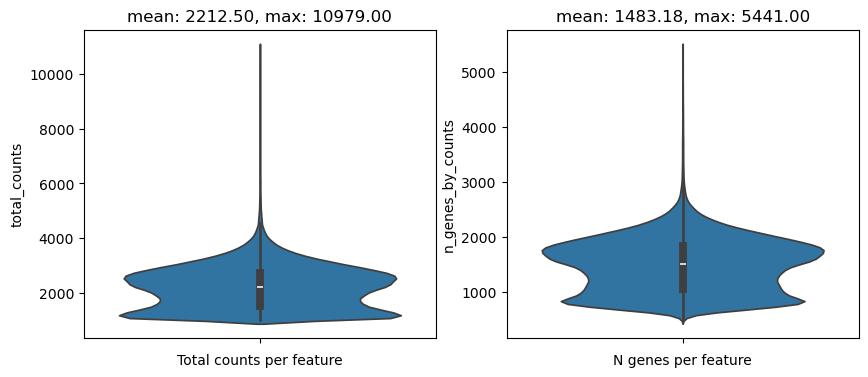

In [23]:
#generate QC plot
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
count_array = adata_bin.obs["total_counts"]
sns.violinplot(y = count_array, ax=axs[0])
axs[0].set_xlabel('Total counts per feature')
axs[0].title.set_text('mean: %.2f, max: %.2f' % (count_array.mean(), count_array.max()))
ngene_array = adata_bin.obs["n_genes_by_counts"]
sns.violinplot(y = ngene_array, ax=axs[1])
axs[1].set_xlabel('N genes per feature')
axs[1].title.set_text('mean: %.2f, max: %.2f' % (ngene_array.mean(), ngene_array.max()))
# fig.savefig(f'{output_dir}/qc_tissue2.png')
#axs[0].grid(False)
#axs[1].grid(False)

In [24]:
adata_bin

AnnData object with n_obs × n_vars = 390592 × 17658
    obs: 'array_col', 'array_row', 'ngenes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes'
    var: 'gene_ids', 'total_counts', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'log1p_total_counts', 'n_cells'
    uns: 'bin_size', 'conv_size', 'l', 'l2', 'l3', 'log1p'

In [ ]:
# adata_bin.write(f"/path/to/file/binned_filtered_{bin_size}_{sample_name}_features.h5ad", compression='lzf')